# Engine Start-Stop Demo

This demo simulates a conventional vehicle over a drive cycle with and
without engine start-stop, which turns the engine off while the vehicle
is stopped, and compares the resulting fuel economy. It then converts
the vehicle to a micro hybrid electric vehicle (uHEV) with a small
battery and electric machine that supplies auxiliary loads when
feasible, including while the engine is off.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure

import fastsim as fsim
from plot_utils import get_paired_cycler, get_uni_cycler

In [2]:

# if environment var `SHOW_PLOTS=false` is set, no plots are shown
SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
# if environment var `SAVE_FIGS=true` is set, save plots
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

METERS_PER_MILE = 1609.34
MJ_PER_GGE = 125.0

## Setup and Simulation

Run the same vehicle and drive cycle twice: first with the default
powertrain controller, then with the start-stop controller enabled via
`use_start_stop_controller`. The start-stop controller turns the engine
off while the vehicle is stopped, subject to conditions such as a
minimum engine on time and engine warm-up temperature.

In [3]:
# load 2012 Ford Fusion vehicle model
veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

# load cycle from file
cyc = fsim.Cycle.from_resource("udds.csv")

# instantiate `SimDrive` simulation object and run
sd = fsim.SimDrive(veh, cyc)
sd.walk()
df = sd.to_dataframe()

In [4]:
# load 2012 Ford Fusion vehicle model with start-stop controller
veh_ss = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh_ss.use_start_stop_controller()
veh_ss.set_save_interval(1)

sd_ss = fsim.SimDrive(veh_ss, cyc)
sd_ss.walk()
df_ss = sd_ss.to_dataframe()

## Fuel Economy Comparison

Compute fuel economy for both runs from cumulative fuel energy and cycle
distance, then print the percent reduction in fuel use from start-stop.

In [5]:
cyc_dict = cyc.to_pydict()
distance_m = cyc_dict["dist_meters"][-1]
distance_mi = distance_m / METERS_PER_MILE

fuel_mj = df["veh.pt_type.Conv.fc.history.energy_fuel_joules"].iloc[-1] / 1e6
fuel_ss_mj = df_ss["veh.pt_type.Conv.fc.history.energy_fuel_joules"].iloc[-1] / 1e6

gge_gal = fuel_mj / MJ_PER_GGE
gge_ss_gal = fuel_ss_mj / MJ_PER_GGE
fuel_economy_mpg = distance_mi / gge_gal
fuel_economy_ss_mpg = distance_mi / gge_ss_gal

percent_reduction = (fuel_mj - fuel_ss_mj) * 100.0 / fuel_mj

print(f"Conventional Vehicle Fuel Economy: {fuel_economy_mpg} mpg")
print(f"Conventional w/ Start-Stop       : {fuel_economy_ss_mpg} mpg")
print(f"Start-Stop Reduction in Fuel Usage (Conv): {percent_reduction} %")

Conventional Vehicle Fuel Economy: 35.42212934302861 mpg
Conventional w/ Start-Stop       : 37.54554485688261 mpg
Start-Stop Reduction in Fuel Usage (Conv): 5.655572510528494 %


## Micro Hybrid Conversion

The following function converts the conventional vehicle into a micro
hybrid electric vehicle (uHEV): a vehicle with a small battery and
electric machine that support engine start-stop. The conversion keeps
the original fuel converter, fuel storage, and transmission, adds a
battery and a constant-efficiency electric machine, supplies auxiliary
loads from the battery when feasible (`AuxOnResPriority`), and uses the
hybrid start-stop powertrain controller with optional regenerative
braking. The dictionaries are written out in full to show the fields
available for tweaking.

In [6]:
def conv_to_micro_hybrid(
    veh: fsim.Vehicle,
    res_eff: float | None = None,
    res_capacity_joules: float | None = None,
    em_eff: float | None = None,
    em_max_pwr_w: float | None = None,
    allow_regen: bool = True,
) -> fsim.Vehicle:
    """Build a micro hybrid version of the Ford Fusion."""
    res_eff = 0.90 if res_eff is None else res_eff
    res_capacity_joules = 72_000.0 if res_capacity_joules is None else res_capacity_joules
    em_eff = 0.95 if em_eff is None else em_eff
    em_max_pwr_w = 5_000.0 if em_max_pwr_w is None else em_max_pwr_w
    assert res_capacity_joules > 0.0
    assert res_eff > 0.0 and res_eff <= 1.0, "res_eff must be in range (0.0, 1.0]"
    assert em_eff > 0.0 and em_eff <= 1.0, "em_eff must be in range (0.0, 1.0]"
    veh_dict = veh.to_pydict()
    res = {
        "thrml": "None",
        "mass_kilograms": None,
        "specific_energy_joules_per_kilogram": None,
        "pwr_out_max_watts": em_max_pwr_w,
        "energy_capacity_joules": res_capacity_joules,
        "eff_interp": {
            "Constant": res_eff,
        },
        "min_soc": 0.0,
        "max_soc": 1.0,
        "state": {
            "pwr_prop_max_watts": 0.0,
            "pwr_regen_max_watts": 0.0,
            "pwr_disch_max_watts": 0.0,
            "pwr_charge_max_watts": 0.0,
            "i": 0,
            "soc": 0.5,
            "soc_regen_buffer": 1.0,
            "soc_disch_buffer": 0.0,
            "eff": 0.0,
            "soh": 0.0,
            "pwr_out_electrical_watts": 0.0,
            "pwr_out_prop_watts": 0.0,
            "pwr_aux_watts": 0.0,
            "pwr_loss_watts": 0.0,
            "pwr_out_chemical_watts": 0.0,
            "energy_out_electrical_joules": 0.0,
            "energy_out_prop_joules": 0.0,
            "energy_aux_joules": 0.0,
            "energy_loss_joules": 0.0,
            "energy_out_chemical_joules": 0.0,
        },
        "history": {
            "pwr_prop_max_watts": [],
            "pwr_regen_max_watts": [],
            "pwr_disch_max_watts": [],
            "pwr_charge_max_watts": [],
            "i": [],
            "soc": [],
            "soc_regen_buffer": [],
            "soc_disch_buffer": [],
            "eff": [],
            "soh": [],
            "pwr_out_electrical_watts": [],
            "pwr_out_prop_watts": [],
            "pwr_aux_watts": [],
            "pwr_loss_watts": [],
            "pwr_out_chemical_watts": [],
            "energy_out_electrical_joules": [],
            "energy_out_prop_joules": [],
            "energy_aux_joules": [],
            "energy_loss_joules": [],
            "energy_out_chemical_joules": [],
        },
        "save_interval": 1,
    }
    em = {
        "eff_interp_achieved": {
            "data": {
                "grid": [
                    {
                        "v": 1,
                        "dim": [2],
                        "data": [0.0, 1.0],
                    },
                ],
                "values": {
                    "v": 1,
                    "dim": [2],
                    "data": [em_eff, em_eff],
                },
            },
            "strategy": "Linear",
            "extrapolate": "Error",
        },
        "eff_interp_at_max_input": {
            "data": {
                "grid": [
                    {
                        "v": 1,
                        "dim": [2],
                        "data": [0.0, 1.0],
                    },
                ],
                "values": {
                    "v": 1,
                    "dim": [2],
                    "data": [em_eff, em_eff],
                },
            },
            "strategy": "Linear",
            "extrapolate": "Error",
        },
        "pwr_out_max_watts": em_max_pwr_w,
        "specific_pwr_watts_per_kilogram": None,
        "mass_kilograms": None,
        "save_interval": 1,
        "state": {
            "i": 0,
            "eff": 0.0,
            "pwr_mech_fwd_out_max_watts": 0.0,
            "eff_fwd_at_max_input": 0.0,
            "pwr_mech_regen_max_watts": 0.0,
            "eff_at_max_regen": 0.0,
            "pwr_out_req_watts": 0.0,
            "energy_out_req_joules": 0.0,
            "pwr_elec_prop_in_watts": 0.0,
            "energy_elec_prop_in_joules": 0.0,
            "pwr_mech_prop_out_watts": 0.0,
            "energy_mech_prop_out_joules": 0.0,
            "pwr_mech_dyn_brake_watts": 0.0,
            "energy_mech_dyn_brake_joules": 0.0,
            "pwr_elec_dyn_brake_watts": 0.0,
            "energy_elec_dyn_brake_joules": 0.0,
            "pwr_loss_watts": 0.0,
            "energy_loss_joules": 0.0,
        },
        "history": {
            "i": [],
            "eff": [],
            "pwr_mech_fwd_out_max_watts": [],
            "eff_fwd_at_max_input": [],
            "pwr_mech_regen_max_watts": [],
            "eff_at_max_regen": [],
            "pwr_out_req_watts": [],
            "energy_out_req_joules": [],
            "pwr_elec_prop_in_watts": [],
            "energy_elec_prop_in_joules": [],
            "pwr_mech_prop_out_watts": [],
            "energy_mech_prop_out_joules": [],
            "pwr_mech_dyn_brake_watts": [],
            "energy_mech_dyn_brake_joules": [],
            "pwr_elec_dyn_brake_watts": [],
            "energy_elec_dyn_brake_joules": [],
            "pwr_loss_watts": [],
            "energy_loss_joules": [],
        },
    }
    pt_cntrl = {
        "StartStop": {
            "fc_min_time_on_seconds": None,
            "soc_fc_forced_on": None,
            "frac_of_most_eff_pwr_to_run_fc": None,
            "temp_fc_forced_on_kelvin": None,
            "temp_fc_allowed_off_kelvin": None,
            "time_delay_after_stop_until_fc_can_turn_off_seconds": None,
            "em_can_regen": allow_regen,
            "save_interval": 1,
            "state": {
                "i": 0,
                "fc_temperature_too_low": False,
                "vehicle_not_stopped": False,
                "on_time_too_short": False,
                "aux_power_demand": False,
                "charging_for_low_soc": False,
                "time_vehicle_stopped_seconds": 0.0,
                "vehicle_not_stopped_long_enough": False,
                "has_traction_power_request": False,
            },
            "history": {
                "i": [],
                "fc_temperature_too_low": [],
                "vehicle_not_stopped": [],
                "on_time_too_short": [],
                "aux_power_demand": [],
                "charging_for_low_soc": [],
                "time_vehicle_stopped_seconds": [],
                "vehicle_not_stopped_long_enough": [],
                "has_traction_power_request": [],
            },
        },
    }
    sim_params = {
        "res_per_fuel_lim": 0.005,
        "soc_balance_iter_err": 5,
        "balance_soc": True,
        "save_soc_bal_iters": False,
    }
    # NOTE: The value of 11.9 kW below is the approximate idle fuel consumption of the
    # conventional version of the vehicle. In theory, this could be much lower as the
    # accessories can be supplied electrically (thus alleviating the need for engine on).
    # NOTE: if pwr_idle_fuel_watts is too low or zero, the engine effectively uses DFCO
    # behavior where it "shuts off" (i.e., technically on but using no fuel) if no
    # tractive effort is demanded.
    veh_dict["pt_type"]["Conv"]["fc"]["pwr_idle_fuel_watts"] = 11_900.0
    veh_dict["pt_type"] = {
        "HEV": {
            "res": res,
            "fs": veh_dict["pt_type"]["Conv"]["fs"],
            "fc": veh_dict["pt_type"]["Conv"]["fc"],
            "em": em,
            "transmission": veh_dict["pt_type"]["Conv"]["transmission"],
            "pt_cntrl": pt_cntrl,
            "aux_cntrl": "AuxOnResPriority",
            "mass_kilograms": None,
            "sim_params": sim_params,
        },
    }
    veh_uhev = fsim.Vehicle.from_pydict(veh_dict)
    return veh_uhev

In [7]:
veh_uhev = conv_to_micro_hybrid(veh)
sd_uhev = fsim.SimDrive(veh_uhev, cyc)
sd_uhev.walk()
df_uhev = sd_uhev.to_dataframe()

In [8]:
# uHEV reduction in fuel usage
fuel_uhev_mj = df_uhev["veh.pt_type.HEV.fc.history.energy_fuel_joules"].iloc[-1] / 1e6
gge_uhev_gal = fuel_uhev_mj / MJ_PER_GGE
fuel_economy_uhev_mpg = distance_mi / gge_uhev_gal

percent_reduction = (fuel_mj - fuel_uhev_mj) * 100.0 / fuel_mj

print(f"Conventional Vehicle Fuel Economy: {fuel_economy_mpg} mpg")
print(f"Micro HEV Fuel Economy           : {fuel_economy_uhev_mpg} mpg")
print(f"Start-Stop Reduction in Fuel Usage (uHEV): {percent_reduction} %")

Conventional Vehicle Fuel Economy: 35.42212934302861 mpg
Micro HEV Fuel Economy           : 33.36724463231752 mpg
Start-Stop Reduction in Fuel Usage (uHEV): -6.158388963051646 %


## Visualize Results

The following plots compare fuel converter behavior between the runs.

In [9]:
def plot_fc_pwr(df: pd.DataFrame, df_ss: pd.DataFrame, is_hev: bool = False) -> tuple[Figure, Axes]:
    """Plot fuel converter powers."""
    num_subplots = 4 if is_hev else 3
    fig, ax = plt.subplots(num_subplots, 1, sharex=True, figsize=(10, 9))
    title_postfix = " (uHEV)" if is_hev else ""
    plt.suptitle("Fuel Converter Power" + title_postfix)
    tag = "HEV" if is_hev else "Conv"

    ax[0].set_prop_cycle(get_paired_cycler())
    ax[0].plot(
        df["cyc.time_seconds"],
        (
            df["veh.pt_type.Conv.fc.history.pwr_prop_watts"]
            + df["veh.pt_type.Conv.fc.history.pwr_aux_watts"]
        )
        / 1e3,
        label="f3 shaft",
    )
    ax[0].plot(
        df_ss["cyc.time_seconds"],
        (
            df_ss[f"veh.pt_type.{tag}.fc.history.pwr_prop_watts"]
            + df_ss[f"veh.pt_type.{tag}.fc.history.pwr_aux_watts"]
        )
        / 1e3,
        label="f3 shaft (ss)",
    )
    ax[0].set_ylabel("FC Power [kW]")
    ax[0].legend()

    ax[1].set_prop_cycle(get_paired_cycler())
    ax[1].plot(
        df["cyc.time_seconds"],
        df["veh.pt_type.Conv.fc.history.pwr_fuel_watts"] / 1e3,
        label="f3 fuel",
    )
    ax[1].plot(
        df_ss["cyc.time_seconds"],
        df_ss[f"veh.pt_type.{tag}.fc.history.pwr_fuel_watts"] / 1e3,
        label="f3 fuel (ss)",
    )
    ax[1].set_ylabel("FC Power [kW]")
    ax[1].legend()

    ax[2].set_prop_cycle(get_paired_cycler())
    ax[2].plot(
        df["cyc.time_seconds"],
        df["veh.history.speed_ach_meters_per_second"],
        label="f3",
    )
    ax[2].plot(
        df_ss["cyc.time_seconds"],
        df_ss["veh.history.speed_ach_meters_per_second"],
        label="f3 (ss)",
    )
    ax[2].legend()
    ax[2].set_xlabel("Time [s]")
    ax[2].set_ylabel("Ach Speed [m/s]")
    x_min, x_max = ax[2].get_xlim()[0], ax[2].get_xlim()[1]
    x_max = (x_max - x_min) * 1.15
    ax[2].set_xlim([x_min, x_max])

    if is_hev:
        ax[3].set_prop_cycle(get_uni_cycler())
        ax[3].plot(
            df_ss["cyc.time_seconds"],
            df_ss["veh.pt_type.HEV.res.history.soc"],
            label="soc",
        )
        ax[3].legend()
        ax[3].set_xlabel("Time [s]")
        ax[3].set_ylabel("SOC")
        x_min, x_max = ax[3].get_xlim()[0], ax[3].get_xlim()[1]
        x_max = (x_max - x_min) * 1.15
        ax[3].set_xlim([x_min, x_max])

    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(Path("./plots/fc_pwr.svg"))
    if SHOW_PLOTS:
        plt.show()

    return fig, ax

Fuel converter shaft power, fuel power, and achieved speed for the
baseline and start-stop runs. During stops, the start-stop run's fuel
power drops to zero while the baseline continues to use idle fuel.

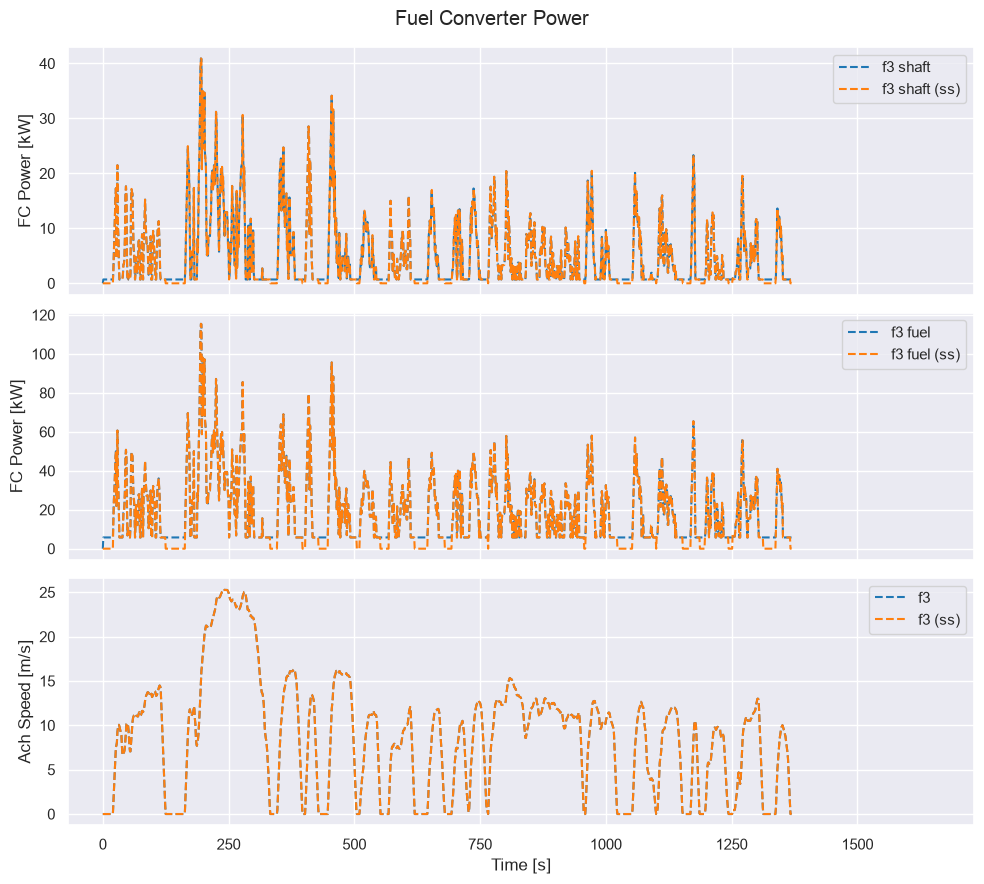

In [10]:
fig, ax = plot_fc_pwr(df, df_ss)

The same comparison for the micro hybrid, with battery state of charge
in the fourth panel.

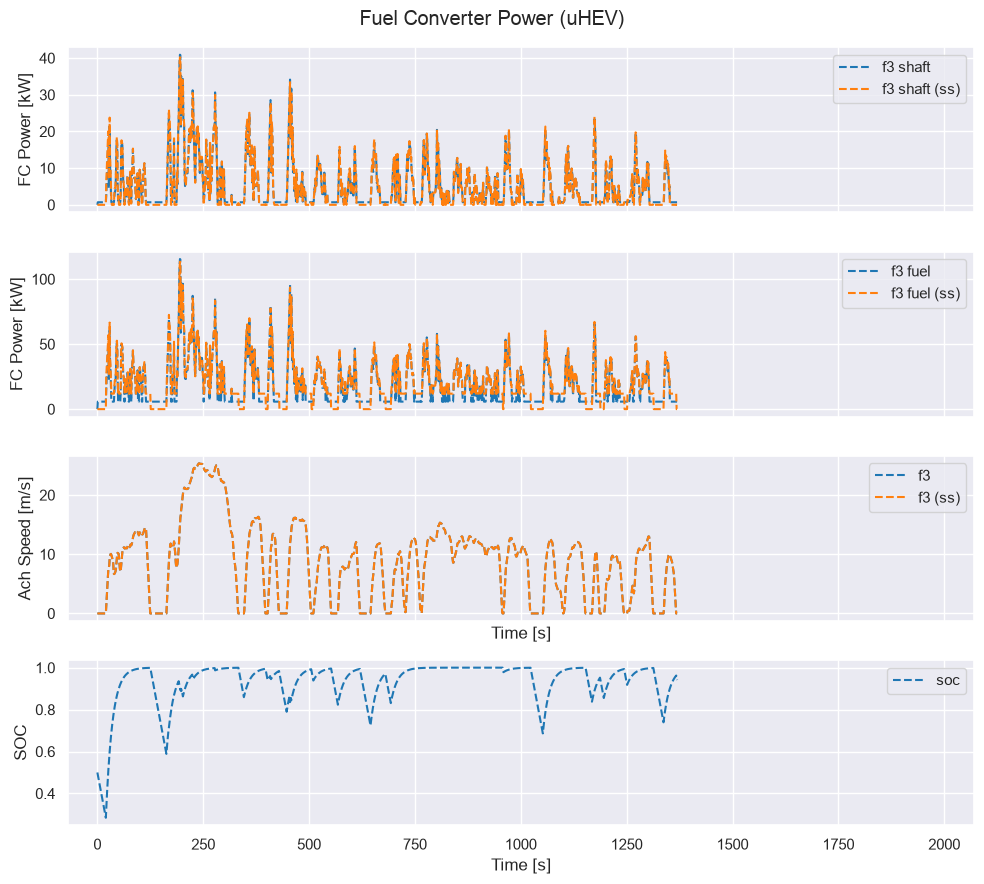

In [11]:
fig2, ax2 = plot_fc_pwr(df, df_uhev, is_hev=True)

In [12]:
def plot_engine_on_flags(df: pd.DataFrame, df_ss: pd.DataFrame, is_hev: bool = False):
    """Plot engine flags."""
    if not is_hev:
        return
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 9))
    plt.suptitle("Fuel Converter On Logic")
    ax[0].set_prop_cycle(get_paired_cycler())
    ax[0].plot(
        df_ss["cyc.time_seconds"],
        df_ss["veh.pt_type.HEV.pt_cntrl.StartStop.history.vehicle_not_stopped"],
        label="not stopped",
    )
    ax[0].legend()

    ax[1].set_prop_cycle(get_paired_cycler())
    ax[1].plot(
        df["cyc.time_seconds"],
        df["veh.history.speed_ach_meters_per_second"],
        label="f3",
    )
    ax[1].plot(
        df_ss["cyc.time_seconds"],
        df_ss["veh.history.speed_ach_meters_per_second"],
        label="f3 (ss)",
    )
    ax[1].legend()
    ax[1].set_xlabel("Time [s]")
    ax[1].set_ylabel("Ach Speed [m/s]")
    x_min, x_max = ax[1].get_xlim()[0], ax[1].get_xlim()[1]
    x_max = (x_max - x_min) * 1.15
    ax[1].set_xlim([x_min, x_max])

    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(Path("./plots/fc_onoff.svg"))
    if SHOW_PLOTS:
        plt.show()

    return fig, ax

The micro hybrid start-stop controller's `vehicle_not_stopped` flag, one
of the conditions that forces the engine on, plotted with achieved speed.

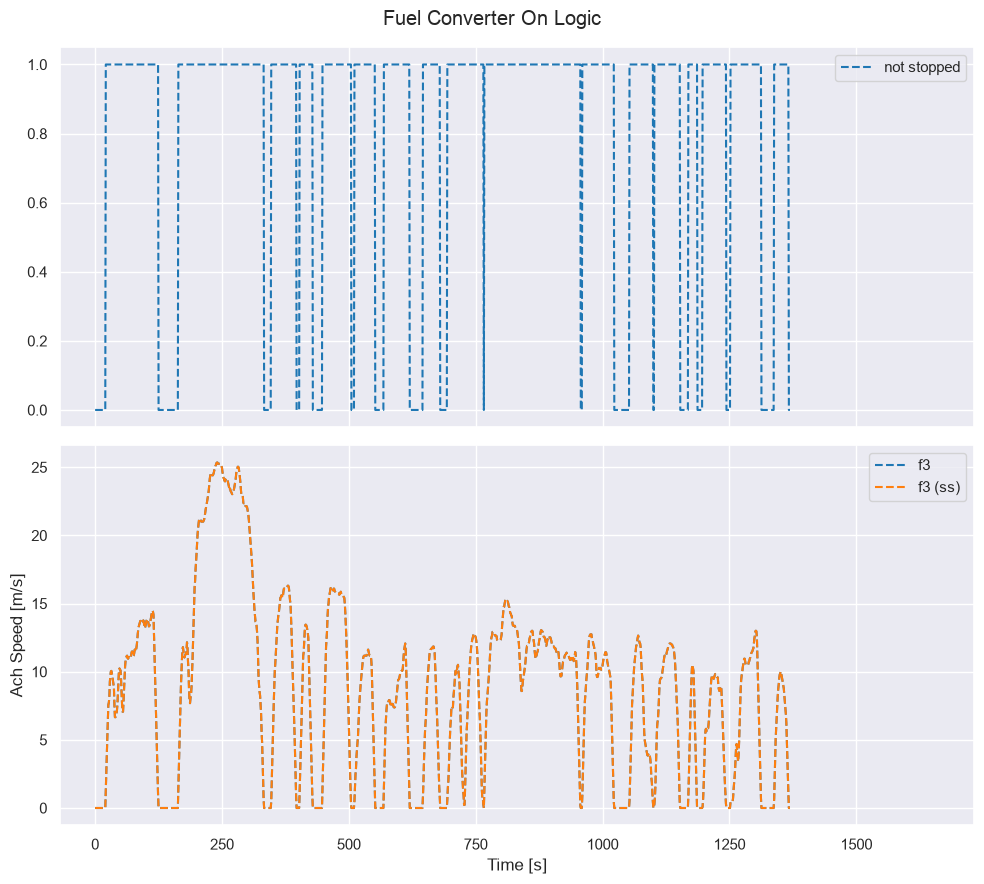

In [13]:
fig3, ax3 = plot_engine_on_flags(df, df_uhev, is_hev=True)